# TinyChirp SincNet-Time TensorFlow

Train a **Conv2D** model (`kernel_size=(k, 1)`) with a SincNet-style learnable frontend directly on raw audio waveforms, export an int8 TFLite model, and write a Rust `audio_sample.rs` file.

This mirrors `building_tensorflow/cnn_time.ipynb` but replaces the first convolutional layer with a custom Sinc-like frontend whose learned filters are later baked into a standard `Conv2D` layer for inference. Rank-4 tensors throughout keep the graph compatible with microflow.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tensorflow as tf

from utils import (
    TARGET_AUDIO_LEN_TIME,
    get_paths,
    configure_tf_runtime,
    set_global_seed,
    make_time_datasets,
)

configure_tf_runtime()
set_global_seed()

MODEL_STEM = "sincnet_multilayer_tf"
paths = get_paths(MODEL_STEM)
OUT_TFLITE = paths.out_tflite
BATCH_SIZE = 32
OUT_AUDIO_RS = paths.out_audio_rs

2026-04-20 15:03:38.059776: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 15:03:38.136102: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-20 15:03:38.178362: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-20 15:03:38.178558: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-20 15:03:38.240978: I tensorflow/core/platform/cpu_feature_gua

In [3]:
def _time_nhwc(audio, label):
    """[B, T, 1] from utils -> [B, T, 1, 1] for Conv2D (time = height)."""
    return tf.expand_dims(audio, -1), label


train_ds, val_ds, test_ds, label_names = make_time_datasets()
train_ds = train_ds.map(_time_nhwc)
val_ds = val_ds.map(_time_nhwc)
test_ds = test_ds.map(_time_nhwc)
num_labels = len(label_names)
print("Classes:", label_names)

Found 11292 files belonging to 2 classes.
Found 1380 files belonging to 2 classes.


2026-04-20 15:03:44.502917: I tensorflow_io/core/kernels/cpu_check.cc:128] Your CPU supports instructions that this TensorFlow IO binary was not compiled to use: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA


Found 1393 files belonging to 2 classes.
Classes: ['non_target' 'target']


## SincNet-style learnable frontend

We define a simplified SincNet-style learnable filterbank as a custom Keras layer that operates directly on the raw waveform. The layer maintains trainable parameters that are passed through a `sin` nonlinearity to produce filters, which are then applied via a Conv2D with kernel shape `(k, 1)` along the time axis.

In [4]:
class CustomFrontend(tf.keras.layers.Layer):
    def __init__(self, num_filters: int, kernel_size: int, stride: int, **kwargs):
        super().__init__(**kwargs)
        self.num_filters = num_filters
        self.kernel_size = kernel_size
        self.stride = stride
        self.params = self.add_weight(
            shape=(kernel_size, 1, num_filters),
            initializer="random_normal",
            trainable=True,
            name="sinc_params",
        )

    def get_filters(self) -> tf.Tensor:
        # [k, in_ch, out_ch] with in_ch=1
        return tf.math.sin(self.params)

    def get_filters_nhwc(self) -> tf.Tensor:
        # Conv2D NHWC kernel: [k_h, k_w, in_ch, out_ch]
        f = self.get_filters()
        return tf.reshape(f, (self.kernel_size, 1, 1, self.num_filters))

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        # inputs: [batch, time, 1, 1]
        return tf.nn.conv2d(
            inputs,
            self.get_filters_nhwc(),
            strides=[1, self.stride, 1, 1],
            padding="VALID",
            data_format="NHWC",
        )

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_filters": self.num_filters,
            "kernel_size": self.kernel_size,
            "stride": self.stride,
        })
        return config

In [5]:
NUM_FILTERS = 48
NUM_FILTERS_2 = 16
DENSE_HIDDEN = 64
KERNEL_SIZE = 32
KERNEL_SIZE_2 = 16
STRIDE = 8
STRIDE_2 = 4

def build_training_model(num_labels: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))
    x = CustomFrontend(
        num_filters=NUM_FILTERS,
        kernel_size=KERNEL_SIZE,
        stride=STRIDE,
        name="sinc_frontend")(inputs)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Conv2D(
        filters=NUM_FILTERS_2,
        kernel_size=(KERNEL_SIZE_2, 1),
        strides=(STRIDE_2, 1),
        padding="valid",
        use_bias=False,
        name="conv_2",
    )(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.AveragePooling2D(pool_size=(x.shape[1], 1), padding="valid", name="avg_pool")(x)
    x = tf.keras.layers.Flatten(name="flatten")(x)
    x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
    outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
    return tf.keras.Model(inputs, outputs, name="sincnet_multilayer")


training_model = build_training_model(num_labels)
training_model.summary()

Model: "sincnet_multilayer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 47872, 1, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sinc_frontend (CustomFrontend)  │ (None, 5981, 1, 48)    │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 5981, 1, 48)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 1492, 1, 16)    │        12,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 1492, 1, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avg_pool (AveragePooling2D)     │ (None, 1, 1, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_logits (Dense)            │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,042 (58.76 KB)

 Trainable params: 15,042 (58.76 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
from utils import init_wandb, get_callbacks, finish_wandb

training_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)

init_wandb(MODEL_STEM, config={
    "num_filters": NUM_FILTERS,
    "num_filters_2": NUM_FILTERS_2,
    "kernel_size": KERNEL_SIZE,
    "kernel_size_2": KERNEL_SIZE_2,
    "stride": STRIDE,
    "stride_2": STRIDE_2,
    "dense_hidden": DENSE_HIDDEN,
})

history = training_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    validation_steps=44,
    callbacks=get_callbacks(10,5,BATCH_SIZE)
)
finish_wandb()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/nathan/.netrc.
wandb: Currently logged in as: nathan-duboisset (nathan-duboisset-cole-polytechnique) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1/100


I0000 00:00:1776690228.523594   40526 service.cc:145] XLA service 0x7f9a04003300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776690228.523646   40526 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-04-20 15:03:48.580005: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-20 15:03:48.813419: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 11/353 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6785 - loss: 0.6786

I0000 00:00:1776690231.591558   40526 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


353/353 ━━━━━━━━━━━━━━━━━━━━ 27s 65ms/step - accuracy: 0.8004 - loss: 0.3994 - val_accuracy: 0.9109 - val_loss: 0.2502
Epoch 2/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.9077 - loss: 0.2192 - val_accuracy: 0.9493 - val_loss: 0.1505
Epoch 3/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9439 - loss: 0.1595 - val_accuracy: 0.9688 - val_loss: 0.1150
Epoch 4/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.9562 - loss: 0.1386 - val_accuracy: 0.9710 - val_loss: 0.1024
Epoch 5/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.9586 - loss: 0.1232 - val_accuracy: 0.9746 - val_loss: 0.0908
Epoch 6/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9627 - loss: 0.1087 - val_accuracy: 0.9783 - val_loss: 0.0814
Epoch 7/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 27s 76ms/step - accuracy: 0.9660 - loss: 0.0966 - val_accuracy: 0.9783 - val_loss: 0.0706
Epoch 8/100
353/353 ━━━━━━━━━━━━━━━━━━━━ 26s 73ms/step - accuracy: 0.9718 - loss: 0.0832 - val_

batch/accuracy,▁▅▅▅▇▇▇▇▇███████████████████████████████
batch/batch_step,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
batch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
batch/loss,█▅▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▂▁▁▁▁▁▂▂▁▁▁
epoch/accuracy,▁▅▆▇▇▇▇▇█████████████████████
epoch/epoch,▁▁▁▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇██
epoch/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/loss,█▅▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch/val_accuracy,▁▄▆▆▇▇▇▇▇▇███████████████████
epoch/val_loss,█▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+6,...


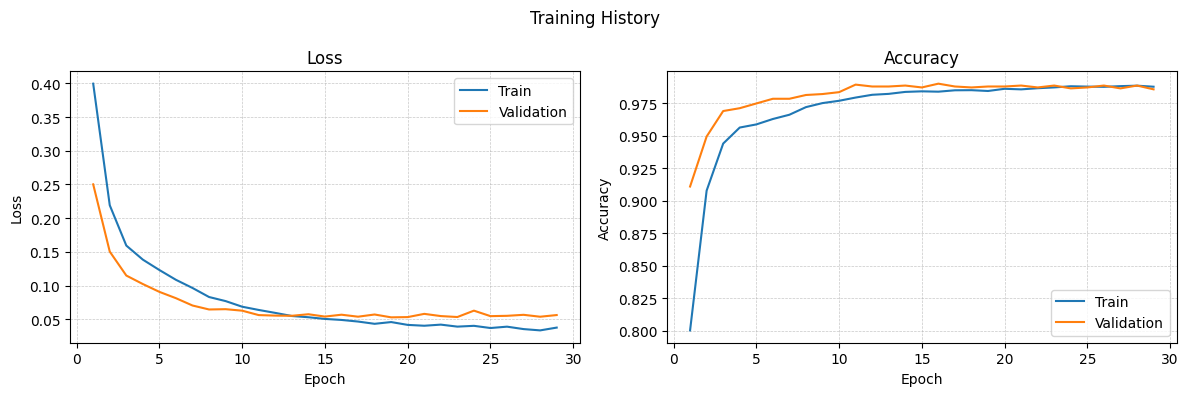

In [7]:
from utils import plot_training_history
plot_training_history(history)

In [8]:
import numpy as np

# Bake CustomFrontend sinc filters into a static Conv2D for TFLite export
custom_layer = training_model.get_layer("sinc_frontend")
baked_filters = custom_layer.get_filters().numpy().reshape((KERNEL_SIZE, 1, 1, NUM_FILTERS))

infer_inputs = tf.keras.Input(shape=(TARGET_AUDIO_LEN_TIME, 1, 1))
x = tf.keras.layers.Conv2D(
    filters=NUM_FILTERS, kernel_size=(KERNEL_SIZE, 1), strides=(STRIDE, 1),
    padding="valid", use_bias=False, name="baked_conv"
)(infer_inputs)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.Conv2D(
    filters=NUM_FILTERS_2, kernel_size=(KERNEL_SIZE_2, 1), strides=(STRIDE_2, 1),
    padding="valid", use_bias=False, name="conv_2"
)(x)
x = tf.keras.layers.ReLU()(x)
x = tf.keras.layers.AveragePooling2D(pool_size=(x.shape[1], 1), padding="valid", name="avg_pool")(x)
x = tf.keras.layers.Flatten(name="flatten")(x)
x = tf.keras.layers.Dense(DENSE_HIDDEN, activation="relu", name="dense_hidden")(x)
outputs = tf.keras.layers.Dense(num_labels, activation=None, name="dense_logits")(x)
inference_model = tf.keras.Model(infer_inputs, outputs, name="sincnet_multilayer_inference")

inference_model.get_layer("baked_conv").set_weights([baked_filters])
inference_model.get_layer("conv_2").set_weights(training_model.get_layer("conv_2").get_weights())
inference_model.get_layer("dense_hidden").set_weights(training_model.get_layer("dense_hidden").get_weights())
inference_model.get_layer("dense_logits").set_weights(training_model.get_layer("dense_logits").get_weights())

for batch_audio, _ in test_ds.take(1):
    logits_train = training_model.predict(batch_audio.numpy(), verbose=0)
    logits_infer = inference_model.predict(batch_audio.numpy(), verbose=0)
    print(f"Max abs diff: {np.max(np.abs(logits_train - logits_infer)):.8f}")

Max abs diff: 0.00000000


2026-04-20 15:16:51.774157: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [9]:
from utils import build_representative_batches, export_keras_model_to_int8_tflite

rep_batches = build_representative_batches(test_ds, take=100)
try:
    export_keras_model_to_int8_tflite(inference_model, rep_batches, OUT_TFLITE)
    print(f"Success! Wrote {OUT_TFLITE}")
except Exception as e:
    print(f"TFLite conversion failed: {e}")

2026-04-20 15:16:52.122783: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Saved artifact at '/tmp/tmpxfhxyue6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 47872, 1, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(1, 2), dtype=tf.float32, name=None)
Captures:
  140304016574064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304016575296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304016575120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304016576352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304016575472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140304016576704: TensorSpec(shape=(), dtype=tf.resource, name=None)


W0000 00:00:1776691012.387131   40431 tf_tfl_flatbuffer_helpers.cc:390] Ignored output_format.
W0000 00:00:1776691012.387147   40431 tf_tfl_flatbuffer_helpers.cc:393] Ignored drop_control_dependency.
2026-04-20 15:16:52.387713: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpxfhxyue6
2026-04-20 15:16:52.388117: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-20 15:16:52.388124: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpxfhxyue6
2026-04-20 15:16:52.393212: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:388] MLIR V1 optimization pass is not enabled
2026-04-20 15:16:52.393831: I tensorflow/cc/saved_model/loader.cc:234] Restoring SavedModel bundle.
2026-04-20 15:16:52.419040: I tensorflow/cc/saved_model/loader.cc:218] Running initialization op on SavedModel bundle at path: /tmp/tmpxfhxyue6
2026-04-20 15:16:52.425305: I tensorflow/cc/saved_model/loader.cc

Success! Wrote /home/nathan/Documents/tiny-chirp-microflow/models/sincnet_multilayer_tf.tflite


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8
2026-04-20 15:16:52.935352: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:3064] Estimated count of arithmetic ops: 55.378 M  ops, equivalently 27.689 M  MACs


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-04-20 15:17:41.244066: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-20 15:17:47.026252: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Model size : 15.2 KB
Est. MFLOPs: 1.710
=== Binary classifier metrics : TEST SET===
Threshold: 0.5000  (best F2 threshold)
Accuracy : 0.9139
Precision: 0.8029
Recall   : 0.9782
F2 score : 0.9372
=== Binary classifier metrics : TRAIN SET===
AUC      : 0.9784


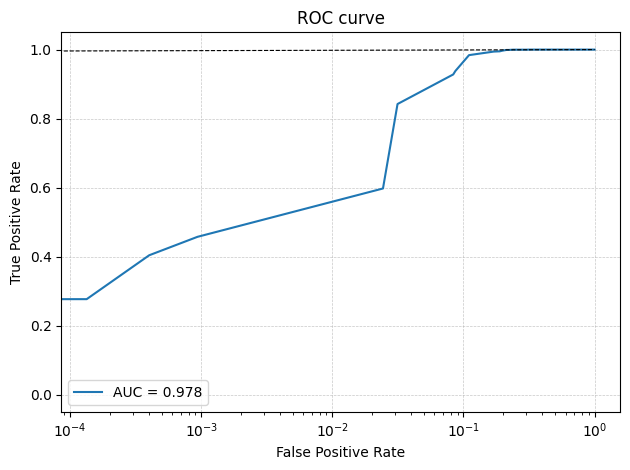

Avg inference: 3.270 ms


In [10]:
from utils import evaluate_tflite_model

train_m, test_m, avg_ms = evaluate_tflite_model(OUT_TFLITE, MODEL_STEM, train_ds, test_ds)
print(f"Avg inference: {avg_ms:.3f} ms")